In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor

e:\Softwares\anaconda3\envs\RAG\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('food_comparison_dataset_swiggy_zomato.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [3]:
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

In [4]:
# Peak meal time
df['peak_meal_time'] = df['time_slot'].apply(
    lambda x: 1 if x in ['Lunch', 'Dinner'] else 0
)

# Demand score
demand_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

df['demand_score'] = df['demand_level'].map(demand_map)

# Total service fee
df['total_service_fee'] = (
    df['delivery_fee'] +
    df['packaging_fee'] +
    df['tax_amount']
)

# Effective discount
df['effective_discount'] = (
    df['coupon_discount'] +
    df['cashback']
)

target = 'final_price'

features = [
    'platform',
    'restaurant_name',
    'restaurant_id',
    'food_item',
    'category',
    'food_price',
    'delivery_fee',
    'packaging_fee',
    'tax_amount',
    'delivery_time_min',
    'restaurant_rating',
    'review_count',
    'available_coupon',
    'coupon_discount',
    'cashback',
    'free_delivery',
    'demand_level',
    'time_slot',
    'day_of_week',
    'festival_indicator',
    'month',
    'day',
    'is_weekend',
    'peak_meal_time',
    'demand_score',
    'total_service_fee',
    'effective_discount'
]

X = df[features].copy()
y = df[target]

In [5]:
categorical_features = [
    'platform',
    'restaurant_name',
    'restaurant_id',
    'food_item',
    'category',
    'free_delivery',
    'demand_level',
    'time_slot',
    'day_of_week'
]

label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [6]:
numerical_features = [
    col for col in features
    if col not in categorical_features
]

scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

correlations = X[numerical_features].corrwith(y).abs()
attention_weights = correlations / correlations.sum()

print('='*50)
print('ATTENTION FEATURE WEIGHTS')
print('='*50)
print(attention_weights.sort_values(ascending=False))
print('='*50)

for col in numerical_features:
    X[col] = X[col] * attention_weights[col]

ATTENTION FEATURE WEIGHTS
food_price            0.288978
tax_amount            0.283550
total_service_fee     0.162834
packaging_fee         0.070511
available_coupon      0.032218
effective_discount    0.027758
review_count          0.027673
delivery_fee          0.026015
coupon_discount       0.025813
restaurant_rating     0.020725
demand_score          0.008103
cashback              0.008101
peak_meal_time        0.007928
delivery_time_min     0.004821
month                 0.002284
festival_indicator    0.001424
is_weekend            0.000939
day                   0.000324
dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 169.6891663	test: 161.8240396	best: 161.8240396 (0)	total: 157ms	remaining: 1m 49s
100:	learn: 16.3634293	test: 16.0252693	best: 16.0252693 (100)	total: 839ms	remaining: 4.97s
200:	learn: 6.2379289	test: 7.9872485	best: 7.9872485 (200)	total: 1.47s	remaining: 3.65s
300:	learn: 4.3627197	test: 7.2369443	best: 7.2346598 (298)	total: 2.08s	remaining: 2.76s
400:	learn: 3.5491528	test: 7.0271884	best: 7.0247148 (392)	total: 2.76s	remaining: 2.06s
500:	learn: 3.0209310	test: 6.8772741	best: 6.8772741 (500)	total: 3.54s	remaining: 1.41s
600:	learn: 2.6527258	test: 6.7779593	best: 6.7779593 (600)	total: 4.2s	remaining: 692ms
699:	learn: 2.3807262	test: 6.6889765	best: 6.6883840 (695)	total: 4.87s	remaining: 0us

bestTest = 6.688383973
bestIteration = 695

Shrink model to first 696 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=700, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [9]:
y_pred = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print('='*60)
print('FOOD AEECF PERFORMANCE')
print('='*60)
print(f'MAE   : {mae:.4f}')
print(f'RMSE  : {rmse:.4f}')
print(f'MAPE  : {mape:.4f}%')
print(f'R²    : {r2:.4f}')
print('='*60)

FOOD AEECF PERFORMANCE
MAE   : 2.4142
RMSE  : 6.6884
MAPE  : 0.9357%
R²    : 0.9984


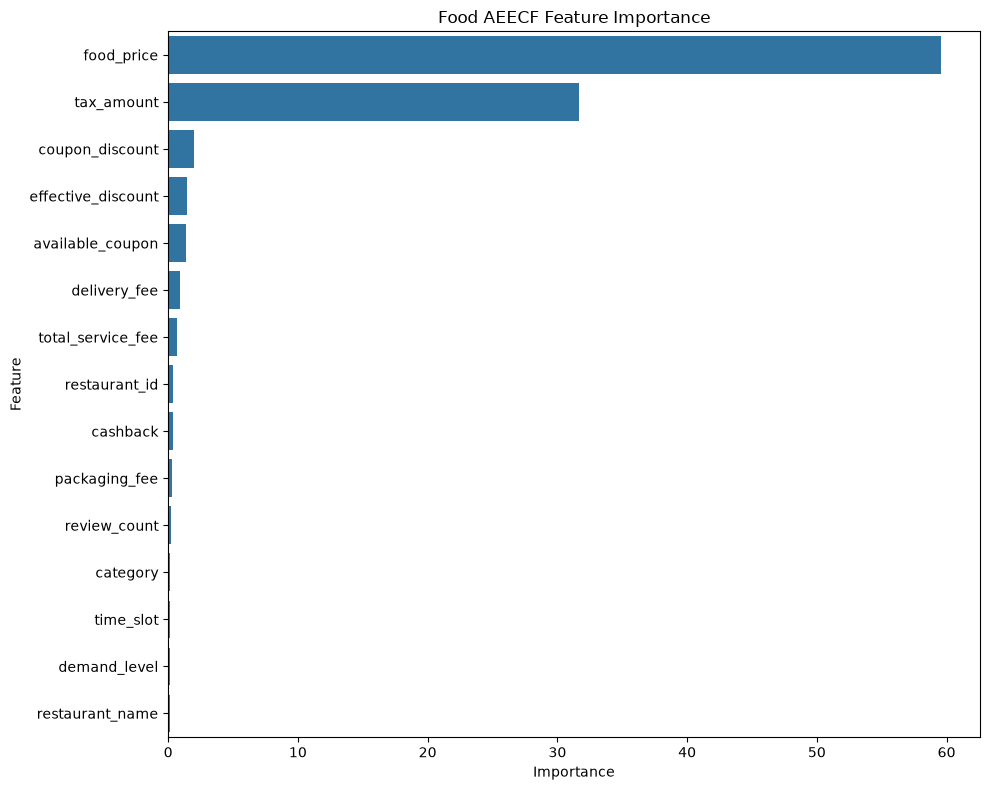

In [11]:
importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Food AEECF Feature Importance')
plt.tight_layout()
plt.savefig('food_feature_importance.png')
plt.show()

In [12]:
explainer = shap.TreeExplainer(model)

sample = X_test.sample(200, random_state=42)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()
plt.savefig('food_shap_summary.png')
plt.close()

In [13]:
residuals = y_test - y_pred
residual_std = residuals.std()

lower_bound = y_pred - 1.96 * residual_std
upper_bound = y_pred + 1.96 * residual_std

confidence = []

for l,u in zip(lower_bound, upper_bound):
    width = u - l
    conf = max(0, 1 - width / max(y))
    confidence.append(conf)

confidence = np.mean(confidence)

print(f'Average Prediction Confidence: {confidence:.4f}')

Average Prediction Confidence: 0.9831


In [14]:
os.makedirs('food_model', exist_ok=True)

joblib.dump(model, 'food_model/aeecf_food_catboost_model.pkl')
joblib.dump(scaler, 'food_model/scaler.pkl')
joblib.dump(label_encoders, 'food_model/label_encoders.pkl')
joblib.dump(attention_weights, 'food_model/attention_weights.pkl')
joblib.dump(features, 'food_model/feature_columns.pkl')

metrics = {
    'MAE':float(mae),
    'RMSE':float(rmse),
    'MAPE':float(mape),
    'R2':float(r2),
    'Confidence':float(confidence)
}

with open('food_model/model_metrics.json','w') as f:
    json.dump(metrics,f,indent=4)

importance_df.to_csv(
    'food_model/feature_importance.csv',
    index=False
)

print('Food AEECF model saved successfully!')

Food AEECF model saved successfully!


In [15]:
def predict_food_price(input_dataframe):
    prediction = model.predict(input_dataframe)
    return prediction

print('Food model ready for Django integration!')

Food model ready for Django integration!
